# Portfolio Optimization — Monte Carlo · S&P 500

Cuaderno **referencial**: optimización Markowitz (Media-Varianza) mediante Monte Carlo vectorizado.
Retornos simples · Anualización geométrica · Horizon-invariant (estadísticas diarias, escaladas a horizonte on-demand) · Rf dinámica.


In [1]:
from pathlib import Path
from datetime import datetime, timedelta

import yfinance as yf
import pandas as pd
import requests
from io import StringIO
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.stats import shapiro, jarque_bera, norm
from scipy.optimize import minimize
import math


## Tasa Libre de Riesgo (Rf)

Para un inversor en USD (vía IBKR → S&P 500), el benchmark sin riesgo es el **T-Bill 3M de EEUU** (`^IRX`):  
- Duración ultracorta → sin riesgo de tipo de interés ni de crédito soberano material  
- Refleja el coste de oportunidad real: lo que obtienes sin asumir riesgo de mercado  
- Se descarga automáticamente en cada ejecución — siempre actualizada

In [2]:
try:
    _tbill = yf.download('^IRX', period='5d', auto_adjust=False, progress=False)
    # yfinance devuelve MultiIndex aunque sea un solo ticker — squeeze() lo colapsa a Series
    RF_ANNUAL = float(_tbill['Close'].squeeze().dropna().iloc[-1]) / 100
    print(f'Rf dinamica (T-Bill 3M):  {RF_ANNUAL*100:.2f}% anual')
except Exception:
    RF_ANNUAL = 0.043
    print(f'Rf estatica (fallback):   {RF_ANNUAL*100:.2f}% anual')

Rf dinamica (T-Bill 3M):  3.67% anual


## 1. Descarga de datos — S&P 500

Composición actual del índice vía Wikipedia. 3 años de precios ajustados, con **fechas pinneadas y cache CSV en `data/`** (mismo criterio que `tries/TimesFM/`): yfinance re-ajusta el histórico retroactivamente con cada dividendo, así que sin pin + cache el notebook no es reproducible.  

**Por qué retornos simples y no log-retornos:**  
- Log-retorno: `ln(Pt/Pt-1)` — aditivo en el tiempo, pero **no aditivo entre activos**. El retorno de una cartera NO es `Σ wᵢ·ln(rᵢ)`.  
- Retorno simple: `(Pt−Pt-1)/Pt-1` — **exactamente aditivo entre activos**: `R_cartera = Σ wᵢ·Rᵢ`. Fundamental para la optimización de pesos.  
- Para retornos diarios pequeños la diferencia numérica es despreciable, pero la propiedad de agregación cross-seccional es correcta solo con simples.

In [3]:
# Wikipedia bloquea urllib sin User-Agent — se usa requests con cabecera de navegador
_headers = {'User-Agent': 'Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36'}
_response = requests.get(
    'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies',
    headers=_headers
)
sp500_table = pd.read_html(StringIO(_response.text))[0]
# yfinance usa '-' en lugar de '.' (ej: BRK.B -> BRK-B)
tickers = sp500_table['Symbol'].str.replace('.', '-', regex=False).tolist()
print(f'Componentes S&P 500: {len(tickers)} tickers')

# Fechas pinneadas + cache CSV — yfinance re-ajusta el historico retroactivamente con
# cada dividendo; sin esto el notebook no es reproducible (mismo criterio que tries/TimesFM/)
END_DATE   = '2026-07-07'
START_DATE = '2023-07-08'
DATA_DIR   = Path('data')
DATA_DIR.mkdir(exist_ok=True)
PRICES_CSV = DATA_DIR / f'close_sp500_{END_DATE}.csv'

if PRICES_CSV.exists():
    close_data = pd.read_csv(PRICES_CSV, index_col=0, parse_dates=True)
    print(f'Cache: {PRICES_CSV}')
else:
    raw = yf.download(tickers, start=START_DATE, end=END_DATE, auto_adjust=True)
    close_data = raw['Close'] if isinstance(raw.columns, pd.MultiIndex) else raw
    close_data.to_csv(PRICES_CSV)

# Eliminar activos con menos del 80% de datos (IPOs recientes, delistings)
min_obs = int(0.80 * len(close_data))
close_data = close_data.dropna(axis=1, thresh=min_obs)

# Retornos simples: R_t = (P_t - P_{t-1}) / P_{t-1}
returns_df = close_data.pct_change(fill_method=None).dropna(how='all')

print(f'Activos con datos suficientes: {returns_df.shape[1]}')
print(f'Observaciones diarias:          {returns_df.shape[0]}')


Componentes S&P 500: 503 tickers
Cache: data/close_sp500_2026-07-07.csv


Activos con datos suficientes: 497
Observaciones diarias:          749


## 2. Screening — Momentum anual

Señal de momentum simple: `crecimiento = 'si'` si el retorno anual compuesto creció **estrictamente** cada año en los últimos 3 años.  
Es un filtro de tendencia, no una garantía de rendimiento futuro.

In [4]:
# Retorno anual compuesto: producto de (1+r_diario) por año
retorno_anual = ((1 + returns_df).resample('YE').prod() - 1)
retorno_anual.index = retorno_anual.index.year

ultimos_tres = retorno_anual.tail(3)

emp_screening = returns_df.groupby(returns_df.index.year).mean()

def crecimiento_progresivo(col):
    return 'si' if (col.diff().dropna() > 0).all() else 'no'

emp_screening.loc['crecimiento'] = ultimos_tres.apply(crecimiento_progresivo)

In [5]:
pd.set_option('display.max_columns', None)

# Mostrar solo los que pasan el filtro
tickers_momentum = emp_screening.columns[
    emp_screening.loc['crecimiento'] == 'si'
].tolist()

print(f'Activos con momentum progresivo (3 años): {len(tickers_momentum)}')
emp_screening[tickers_momentum].tail(4)

Activos con momentum progresivo (3 años): 70


,ABNB,ADI,ADM,AKAM,AMAT,AMD,AME,APA,BALL,BEN,BF-B,BG,BIIB,CAT,CDW,CI,COP,CRL,CRWD,CSCO,CSX,CVX,DE,DGX,DHI,DXCM,ELV,FAST,GL,GLW,HAL,HSIC,HST,HUM,INTC,ITW,JBHT,KEYS,KO,LH,LIN,MCHP,MDLZ,MGM,MPC,MRK,MRNA,MU,NDSN,NXPI,O,ODFL,ON,OXY,PEP,PFG,PHM,PPG,PSX,SJM,SLB,STT,SWK,TDY,TER,UNP,USB,VLO,VRTX,WY
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024,0.000083,0.000532,-0.001033,-0.000663,0.000404,-0.000334,0.000473,-0.001356,-0.000009,-0.001086,-0.001406,-0.000802,-0.001957,0.001009,-0.000863,-0.000145,-0.000414,-0.000712,0.001607,0.00082,-0.00014,0.000124,0.000398,0.000522,-0.00008,-0.001132,-0.000812,0.000611,0.000854,0.002021,-0.000897,-0.000222,-0.00012,-0.001951,-0.003037,0.000009,-0.000445,0.000232,0.00037,0.000182,0.000166,-0.001415,-0.000602,-0.000784,0.00001,-0.000167,-0.002722,0.000489,-0.000784,-0.000079,-0.000025,-0.000309,-0.000699,-0.000593,-0.000261,0.00016,0.000427,-0.000746,-0.000361,-0.000299,-0.000972,0.001133,-0.000458,0.000257,0.000999,-0.000137,0.000702,0.000049,0.00008,-0.000624
2025,0.000403,0.001343,0.000833,-0.000011,0.002283,0.00299,0.000649,0.001017,0.000038,0.001072,-0.001089,0.000882,0.000768,0.00209,-0.000715,0.000297,0.000133,0.000916,0.001662,0.001267,0.000638,0.000503,0.000582,0.000737,0.000446,-0.000234,0.00014,0.000641,0.00107,0.002785,0.000637,0.000511,0.000454,0.000478,0.003222,0.000084,0.000891,0.001164,0.00064,0.000518,0.000199,0.001221,-0.000194,0.000551,0.000939,0.000556,-0.000464,0.005686,0.000774,0.000664,0.000522,-0.000131,0.000077,-0.000382,0.000027,0.000831,0.000567,-0.000337,0.000899,-0.000136,0.000391,0.001375,0.000272,0.00049,0.002414,0.00025,0.000757,0.001537,0.000709,-0.000411
2026,0.00089,0.003218,0.002679,0.00299,0.007501,0.008636,0.001291,0.002828,0.001552,0.003295,0.000433,0.001853,0.001607,0.004594,0.000501,0.000383,0.00113,0.001693,0.004789,0.003541,0.002525,0.001065,0.002766,0.001834,0.000994,0.000967,0.001599,0.001708,0.001994,0.007767,0.001515,0.001217,0.002653,0.004039,0.011064,0.001055,0.003088,0.004098,0.001538,0.001144,0.001985,0.00313,0.00101,0.002396,0.004339,0.001739,0.009192,0.011468,0.001743,0.002734,0.001176,0.002931,0.005523,0.001733,0.000242,0.002117,0.001188,0.001846,0.002866,0.001414,0.001725,0.002754,0.002245,0.002153,0.006759,0.001802,0.001565,0.00444,0.001424,0.000185
crecimiento,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si


## 3. Selección de activos

6 activos de **sectores distintos** del S&P 500. La diversificación sectorial reduce correlación entre activos, que es el mecanismo central de la reducción de varianza en Markowitz: `σ²_p = Σᵢ Σⱼ wᵢwⱼ·Cov(i,j)`.  
A menor correlación entre pares, menor varianza de cartera para el mismo retorno esperado.

| Ticker | Sector |
|--------|--------|
| MSFT | Tecnología |
| JPM | Financiero |
| JNJ | Salud |
| XOM | Energía |
| AMZN | Consumo discrecional |
| NEE | Utilities |

In [6]:
selected_cols = ['MSFT', 'JPM', 'JNJ', 'XOM', 'AMZN', 'NEE']
df_returns = returns_df[selected_cols].dropna().copy()

print(f'Observaciones disponibles: {len(df_returns)} dias')
df_returns.describe().round(4)

Observaciones disponibles: 749 dias


,MSFT,JPM,JNJ,XOM,AMZN,NEE
count,749.0000,749.0000,749.0000,749.0000,749.0000,749.0000
mean,0.0004,0.0013,0.0008,0.0006,0.0011,0.0005
std,0.0154,0.0145,0.0113,0.0146,0.0197,0.0172
min,-0.0999,-0.0748,-0.0759,-0.0720,-0.0898,-0.0897
25%,-0.0072,-0.0054,-0.0049,-0.0078,-0.0099,-0.0084
50%,0.0011,0.0018,0.0008,0.0008,0.0008,0.0010
75%,0.0088,0.0089,0.0066,0.0097,0.0130,0.0102
max,0.1013,0.1154,0.0619,0.0499,0.1198,0.0699


## 4. Distribución de retornos — Test de normalidad

La optimización Media-Varianza asume retornos normalmente distribuidos. En la práctica, los retornos de acciones muestran dos desviaciones clave:

- **Fat tails (curtosis en exceso > 0)**: colas más gruesas que en la normal → crashes extremos más frecuentes. Con fat tails, el intervalo ±1σ captura **menos del 68% real** de los escenarios — el riesgo real es mayor del que σ sugiere.
- **Asimetría negativa (skewness < 0)**: las caídas son más extremas que las subidas del mismo tamaño. La normal es simétrica y no captura esto.

**Tests:**
- *Jarque-Bera*: contrasta skewness y curtosis simultáneamente. p < 0.05 → rechaza normalidad.
- *Shapiro-Wilk*: potente para muestras pequeñas (n < 2000).

**Implicación práctica:** cuando los activos tienen fat tails, el **CVaR₉₅** (pérdida media en el peor 5% de días) es más informativo que σ como medida de riesgo, ya que captura el riesgo de cola que σ subestima.

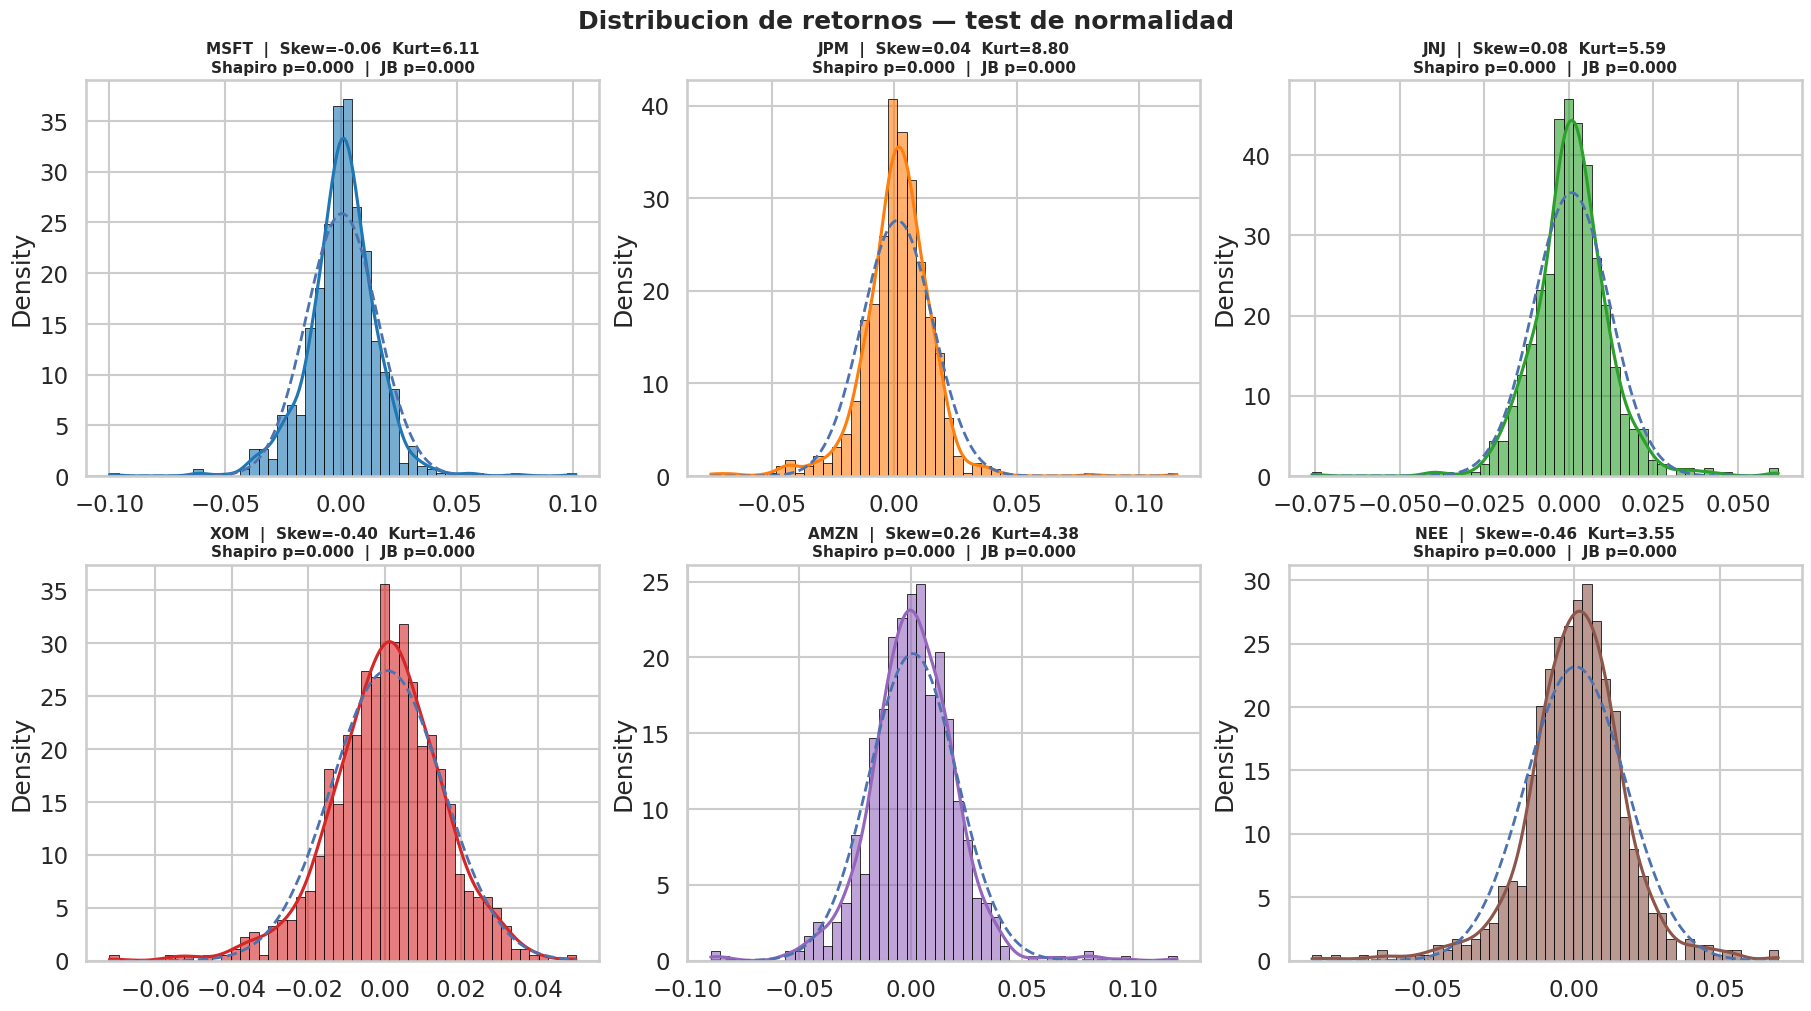


Activos que rechazan normalidad (JB p<0.05): 6/6
Con fat tails presentes, el intervalo ±1σ captura menos del 68% real de escenarios.


,Ticker,Skewness,Kurtosis_exc,JB_p,Normal_JB
0,MSFT,-0.063699,6.111003,6.825774e-250,False
1,JPM,0.040696,8.801182,0.000000e+00,False
2,JNJ,0.081397,5.593281,1.691012e-209,False
3,XOM,-0.403950,1.461497,2.941971e-19,False
4,AMZN,0.256457,4.380622,2.382918e-130,False
5,NEE,-0.458084,3.554684,1.675484e-90,False


In [7]:
sns.set_theme(style='whitegrid', context='talk')
n_assets = df_returns.shape[1]
n_cols = 3
n_rows = math.ceil(n_assets / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows), constrained_layout=True)
axes = axes.flatten()
palette = sns.color_palette('tab10', n_assets)
norm_results = []

for i, col in enumerate(df_returns.columns):
    ax   = axes[i]
    data = df_returns[col].dropna()

    sns.histplot(data, bins=50, kde=True, stat='density', ax=ax,
                 color=palette[i], edgecolor='black', alpha=0.6)

    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 200)
    ax.plot(x, norm.pdf(x, mu, sigma), '--', lw=2, label='Normal teorica')

    _, shapiro_p = shapiro(data)
    _, jb_p      = jarque_bera(data)
    skew         = data.skew()
    kurt_exc     = data.kurt()  # curtosis en exceso (normal = 0)

    norm_results.append({
        'Ticker': col, 'Mean': mu, 'Std': sigma,
        'Skewness': skew, 'Kurtosis_exc': kurt_exc,
        'Shapiro_p': shapiro_p, 'JB_p': jb_p
    })

    ax.set_title(
        f'{col}  |  Skew={skew:.2f}  Kurt={kurt_exc:.2f}\n'
        f'Shapiro p={shapiro_p:.3f}  |  JB p={jb_p:.3f}',
        fontsize=11, fontweight='bold'
    )
    ax.set_xlabel('')
    ax.set_ylabel('Density')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribucion de retornos — test de normalidad', fontsize=18, fontweight='bold')
plt.show()

df_normalidad = pd.DataFrame(norm_results)
df_normalidad['Normal_JB'] = df_normalidad['JB_p'] > 0.05

n_no_normal = (~df_normalidad['Normal_JB']).sum()
print(f'\nActivos que rechazan normalidad (JB p<0.05): {n_no_normal}/{n_assets}')
if n_no_normal > 0:
    print('Con fat tails presentes, el intervalo ±1σ captura menos del 68% real de escenarios.')
df_normalidad[['Ticker', 'Skewness', 'Kurtosis_exc', 'JB_p', 'Normal_JB']]

## 5. Matriz de correlación

ρ < 0.5 entre pares → buena diversificación. Correlaciones altas (> 0.7) indican que dos activos se mueven casi en tándem — combinarlos aporta poco beneficio de diversificación y se puede considerar reducir exposición a uno de ellos.

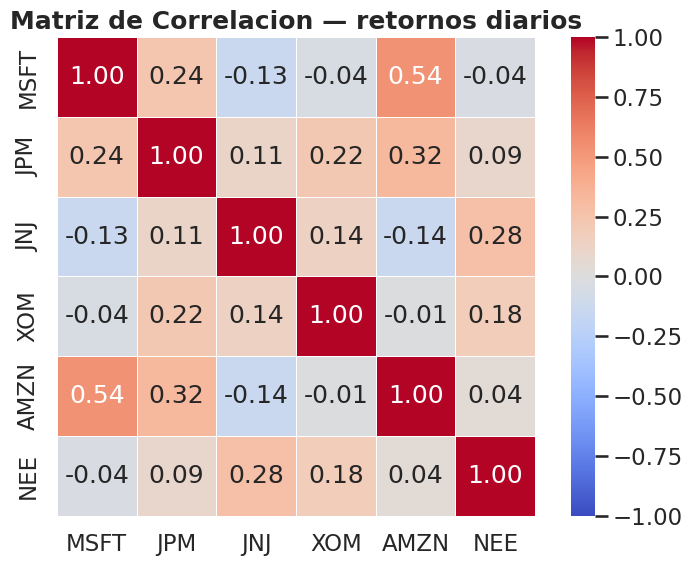

In [8]:
corr = df_returns.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1,
            square=True, linewidths=0.5)
plt.title('Matriz de Correlacion — retornos diarios', fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Simulación Monte Carlo

Generamos 100.000 carteras con pesos aleatorios por activo. Los pesos son **dinámicos**: `min = 2%`, `max = max(20%, 2/n)` — permite más concentración con pocos activos y converge a 20% en n = 10. La función es **vectorizada**: opera sobre matrices en lugar de bucles Python → segundos en lugar de minutos.

**Una única simulación, sin horizonte fijo — igual que en producción (`logic/optimizer.py::run_monte_carlo`).** Bajo retornos i.i.d. y Rf constante, `Sharpe(H) = √H × Sharpe_diario`: el √H es un factor de escala común a todas las carteras, así que la cartera que maximiza el Sharpe (o el Sortino) no depende del horizonte H. Por eso solo se calculan y almacenan **estadísticas diarias** — `mu_d`, `sigma_d`, `dd_d`, `CVaR_95`, `CVaR_95_up` — y el escalado a un horizonte concreto se hace después, en una función aparte (`scale_metrics`), tantas veces como horizontes se quieran comparar, sin volver a simular.

**Reservoir sampling**: en vez de acumular las 100.000 carteras completas en memoria, cada batch se funde en un *reservorio* de tamaño fijo (`sample_size`, por defecto 2.000) quedándonos con una muestra aleatoria uniforme del total simulado (clave aleatoria + `nsmallest`). Es el mismo mecanismo que usa el backend para no inflar la respuesta HTTP ni la memoria del proceso — aquí lo replicamos para que el notebook sea un espejo fiel, aunque en un notebook local no haya esa restricción.

**Métricas por cartera (todas diarias, sin escalar):**
- `R_cartera = Σ wᵢ·Rᵢ` (exacto con retornos simples — propiedad de agregabilidad cross-seccional)
- `mu_d`, `sigma_d`: media y desviación estándar diarias de la cartera.
- `dd_d` — **Downside Deviation diaria**: `√(E[min(r − Rf, 0)²])`. Solo cuenta retornos negativos respecto a Rf; la volatilidad alcista no penaliza. Base del Sortino.
- `CVaR_95` (↓) — pérdida media en el peor 5% de días.
- `CVaR_95_up` (↑) — ganancia media en el mejor 5% de días.
El CVaR se reporta **siempre diario, sin escalar al horizonte** (ver glosario del README).


In [9]:
N_SIMULATIONS = 100_000

def weight_constraints(n):
    """Restricciones dinamicas: min 2%, max = max(20%, 2/n). Converge a 20% en n=10."""
    return 0.02, max(0.20, 2.0 / n)


def run_monte_carlo(df_ret, n_sim, rf_annual, seed=42, batch_size=10_000, sample_size=2_000):
    """
    Monte Carlo vectorizado de carteras aleatorias — replica logic/optimizer.py::run_monte_carlo.

    Almacena solo estadisticas DIARIAS (sin escalar a un horizonte): el escalado se hace
    aparte con `scale_metrics`, ya que el optimo (pesos) es horizon-invariant bajo
    retornos i.i.d. y Rf constante.

    Reservoir sampling: mantiene una muestra aleatoria uniforme de tamano `sample_size`
    del total de carteras simuladas, en vez de acumular las `n_sim` completas en memoria.
    """
    rng      = np.random.default_rng(seed)
    R        = df_ret.values
    T, n     = R.shape
    min_w, max_w = weight_constraints(n)
    rf_daily = (1 + rf_annual) ** (1 / 252) - 1
    k_tail   = max(1, int(0.05 * T))

    reservoir = None
    generated = 0

    with tqdm(total=n_sim, desc='Monte Carlo') as pbar:
        while generated < n_sim:
            need = min(batch_size, n_sim - generated)
            # Muestreo UNIFORME sobre la region factible {w_i in [min_w, max_w], sum w = 1}:
            #   1) Dirichlet(1,...,1) = uniforme sobre el simplex (normalizar exponenciales).
            #      Normalizar uniformes U(0,1) NO es uniforme: sesga los pesos hacia 1/n.
            #   2) Mapa afin  w = min_w + (1 - n*min_w)*v  impone el minimo SIN rechazo
            #      (biyeccion afin del simplex => preserva la uniformidad). Solo se rechaza
            #      el limite superior, lo que da mucha mas aceptacion que rechazar ambos.
            v    = rng.exponential(size=(need * 8, n))
            v   /= v.sum(axis=1, keepdims=True)
            raw  = min_w + (1.0 - n * min_w) * v
            W    = raw[(raw <= max_w).all(axis=1)][:need]
            if len(W) == 0:
                continue

            P = R @ W.T                    # (T, k) retornos diarios de cada cartera

            mu_d    = P.mean(axis=0)
            sigma_d = P.std(axis=0)

            excess = P - rf_daily
            dd_d   = np.sqrt((np.where(excess < 0, excess, 0) ** 2).mean(axis=0))

            sorted_P  = np.sort(P, axis=0)
            cvar_d    = -sorted_P[:k_tail].mean(axis=0)   # downside: perdida media
            cvar_up_d =  sorted_P[-k_tail:].mean(axis=0)  # upside: ganancia media

            b = pd.DataFrame(W, columns=[f'Peso_{c}' for c in df_ret.columns])
            b['mu_d']       = mu_d
            b['sigma_d']    = sigma_d
            b['dd_d']       = dd_d
            b['CVaR_95']    = cvar_d
            b['CVaR_95_up'] = cvar_up_d

            b['_key'] = rng.random(len(W))
            reservoir = b if reservoir is None else pd.concat([reservoir, b], ignore_index=True)
            if len(reservoir) > sample_size:
                reservoir = reservoir.nsmallest(sample_size, '_key')

            generated += len(W)
            pbar.update(len(W))

    return reservoir.drop(columns='_key').reset_index(drop=True)


In [10]:
df_mc = run_monte_carlo(df_returns, N_SIMULATIONS, rf_annual=RF_ANNUAL, seed=42)
print('Monte Carlo OK:', df_mc.shape, f'(muestreadas de {N_SIMULATIONS:,} carteras simuladas)')


Monte Carlo:   0%|          | 0/100000 [00:00<?, ?it/s]

Monte Carlo:  10%|█         | 10000/100000 [00:00<00:04, 21690.52it/s]

Monte Carlo:  20%|██        | 20000/100000 [00:00<00:03, 21089.23it/s]

Monte Carlo:  30%|███       | 30000/100000 [00:01<00:03, 21377.09it/s]

Monte Carlo:  40%|████      | 40000/100000 [00:01<00:02, 20976.34it/s]

...

Monte Carlo:  80%|████████  | 80000/100000 [00:03<00:01, 19213.42it/s]

Monte Carlo:  90%|█████████ | 90000/100000 [00:04<00:00, 16564.78it/s]

Monte Carlo: 100%|██████████| 100000/100000 [00:05<00:00, 15575.32it/s]

Monte Carlo: 100%|██████████| 100000/100000 [00:05<00:00, 18379.17it/s]

Monte Carlo OK: (2000, 11) (muestreadas de 100,000 carteras simuladas)


## 7. Carteras óptimas

A partir de las estadísticas diarias del Monte Carlo, escalamos a un horizonte concreto con `scale_metrics` — sin volver a simular — y localizamos, para cada horizonte, tres carteras clave del espacio de la frontera eficiente:
- **Mínima volatilidad**: menor riesgo absoluto (σ). Preferida cuando se busca preservación de capital — es el vértice izquierdo de la frontera.
- **Máximo Sharpe**: mejor retorno por unidad de riesgo total. Punto tangente de la línea del mercado de capitales (CML) con la frontera eficiente.
- **Máximo Sortino**: mejor retorno por unidad de riesgo **bajista**. Más apropiado que el Sharpe cuando la distribución tiene asimetría negativa (skewness < 0) — los crashes son más extremos que los rallies de igual probabilidad.


In [11]:
def scale_metrics(df, horizon, rf_annual):
    """Escala las stats diarias del Monte Carlo a un horizonte — logica de scaleMetrics() en app.js.
    Retorno: geometrico (1+mu_d)^h - 1. Volatilidad y DD: regla de la raiz del tiempo (x sqrt(h)).
    CVaR se deja diario, sin escalar (ver glosario del README).
    """
    rf_h = (1 + rf_annual) ** (horizon / 252) - 1
    out  = df.copy()
    out['Retorno']     = (1 + out['mu_d']) ** horizon - 1
    out['Volatilidad'] = out['sigma_d'] * np.sqrt(horizon)
    dd_h = out['dd_d'] * np.sqrt(horizon)
    out['Sharpe']  = (out['Retorno'] - rf_h) / out['Volatilidad'].where(out['Volatilidad'] > 0)
    out['Sortino'] = (out['Retorno'] - rf_h) / dd_h.where(dd_h > 0)
    return out


peso_cols   = [c for c in df_mc.columns if c.startswith('Peso_')]
ticker_list = [c.replace('Peso_', '') for c in peso_cols]

rf_q = (1 + RF_ANNUAL) ** (63  / 252) - 1   # Rf trimestral
rf_a = RF_ANNUAL                             # Rf ya esta en escala anual
df_q = scale_metrics(df_mc, 63,  RF_ANNUAL)
df_a = scale_metrics(df_mc, 252, RF_ANNUAL)


def resumen_optimas(df, horizon, rf_h, label):
    idx_vol     = df['Volatilidad'].idxmin()
    idx_sharpe  = df['Sharpe'].idxmax()
    idx_sortino = df['Sortino'].idxmax()

    print(f'\n{"="*70}')
    print(f'HORIZONTE {label} ({horizon}d)   |   Rf={rf_h*100:.2f}%')
    print(f'{"="*70}')
    for nombre, idx in [('Min Volatilidad', idx_vol),
                        ('Max Sharpe',      idx_sharpe),
                        ('Max Sortino',     idx_sortino)]:
        row = df.loc[idx]
        print(f'\n  [{nombre}]')
        print(f'    Retorno:      {row["Retorno"]*100:.2f}%')
        print(f'    Volatilidad:  {row["Volatilidad"]*100:.2f}%')
        print(f'    CVaR 95% ↓:   {row["CVaR_95"]*100:.2f}%')
        print(f'    CVaR 95% ↑:   {row["CVaR_95_up"]*100:.2f}%')
        print(f'    Sharpe:       {row["Sharpe"]:.3f}')
        print(f'    Sortino:      {row["Sortino"]:.3f}')
        pesos = {t: row[f'Peso_{t}']*100 for t in ticker_list}
        print(f'    Pesos: ' + '  '.join([f'{t}={v:.1f}%' for t, v in pesos.items()]))

resumen_optimas(df_q, 63,  rf_q, 'TRIMESTRAL')
resumen_optimas(df_a, 252, rf_a, 'ANUAL')



HORIZONTE TRIMESTRAL (63d)   |   Rf=0.90%

  [Min Volatilidad]
    Retorno:      4.48%
    Volatilidad:  5.84%
    CVaR 95% ↓:   1.61%
    CVaR 95% ↑:   1.60%
    Sharpe:       0.611
    Sortino:      0.893
    Pesos: MSFT=25.7%  JPM=9.9%  JNJ=30.1%  XOM=21.7%  AMZN=5.2%  NEE=7.4%

  [Max Sharpe]
    Retorno:      6.23%
    Volatilidad:  6.65%
    CVaR 95% ↓:   1.86%
    CVaR 95% ↑:   1.89%
    Sharpe:       0.801
    Sortino:      1.192
    Pesos: MSFT=5.1%  JPM=28.3%  JNJ=32.7%  XOM=9.1%  AMZN=20.7%  NEE=3.9%

  [Max Sortino]
    Retorno:      6.23%
    Volatilidad:  6.65%
    CVaR 95% ↓:   1.86%
    CVaR 95% ↑:   1.89%
    Sharpe:       0.801
    Sortino:      1.192
    Pesos: MSFT=5.1%  JPM=28.3%  JNJ=32.7%  XOM=9.1%  AMZN=20.7%  NEE=3.9%

HORIZONTE ANUAL (252d)   |   Rf=3.67%

  [Min Volatilidad]
    Retorno:      19.14%
    Volatilidad:  11.69%
    CVaR 95% ↓:   1.61%
    CVaR 95% ↑:   1.60%
    Sharpe:       1.324
    Sortino:      1.935
    Pesos: MSFT=25.7%  JPM=9.9%  JNJ=30.

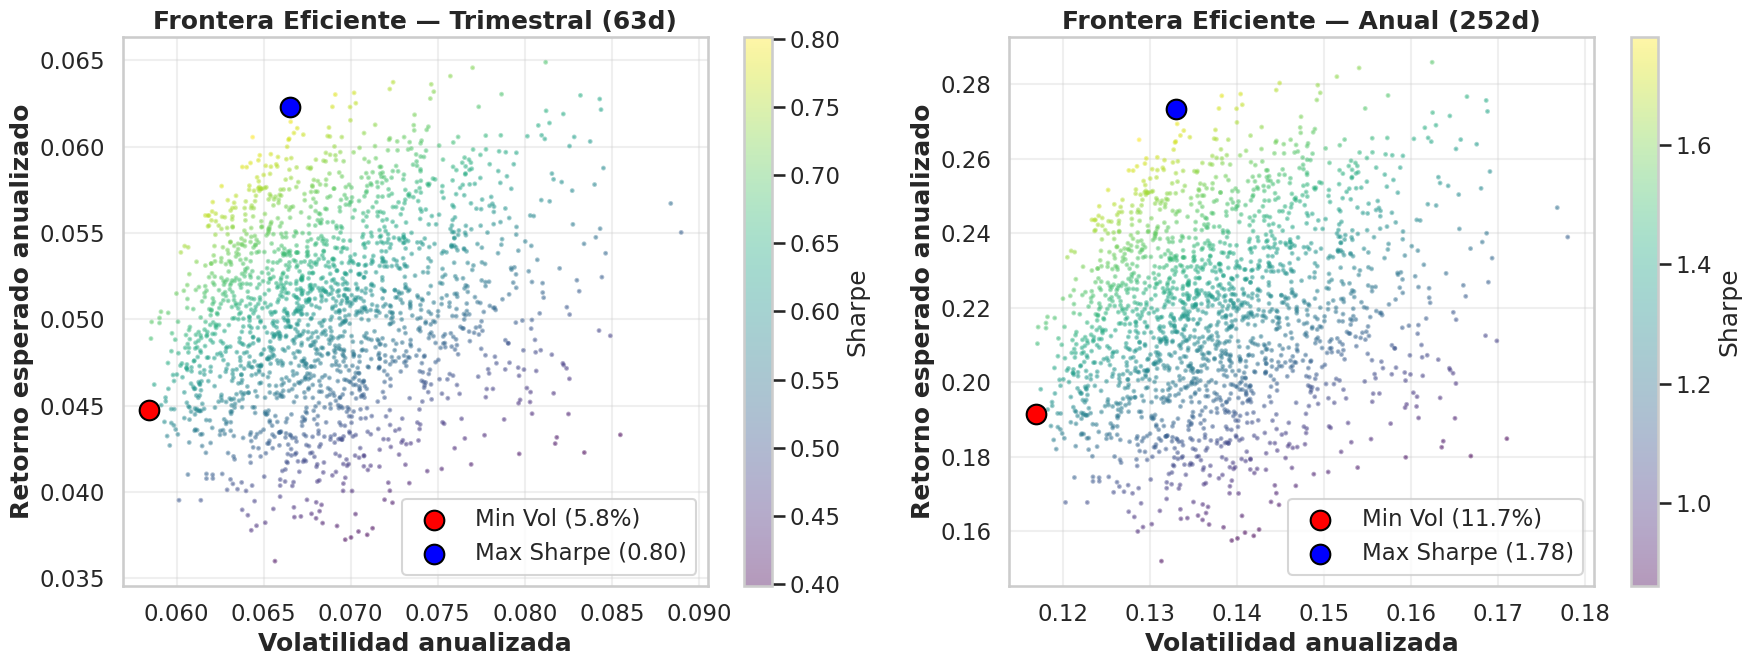

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, df, rf_h, horizon, label in [
    (axes[0], df_q, rf_q, 63,  'Trimestral (63d)'),
    (axes[1], df_a, rf_a, 252, 'Anual (252d)')
]:
    sc = ax.scatter(
        df['Volatilidad'], df['Retorno'],
        c=df['Sharpe'], cmap='viridis', alpha=0.4, s=4
    )

    # Min vol
    idx_v = df['Volatilidad'].idxmin()
    ax.scatter(df.loc[idx_v, 'Volatilidad'], df.loc[idx_v, 'Retorno'],
               color='red', s=200, edgecolor='black', zorder=5,
               label=f'Min Vol ({df.loc[idx_v,"Volatilidad"]*100:.1f}%)')

    # Max Sharpe
    idx_s = df['Sharpe'].idxmax()
    ax.scatter(df.loc[idx_s, 'Volatilidad'], df.loc[idx_s, 'Retorno'],
               color='blue', s=200, edgecolor='black', zorder=5,
               label=f'Max Sharpe ({df.loc[idx_s, "Sharpe"]:.2f})')

    plt.colorbar(sc, ax=ax, label='Sharpe')
    ax.set_xlabel('Volatilidad anualizada', fontweight='bold')
    ax.set_ylabel('Retorno esperado anualizado', fontweight='bold')
    ax.set_title(f'Frontera Eficiente — {label}', fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Optimización exacta — scipy

El Monte Carlo encuentra el *mejor de N muestras aleatorias*, no el óptimo matemático. Con `scipy.optimize.minimize` (método SLSQP) resolvemos analíticamente **tres carteras óptimas**:

| Cartera | Objetivo | Cuándo usarla |
|---------|----------|---------------|
| **Min Volatilidad** | minimizar σ | Preservación de capital, perfil conservador |
| **Max Sharpe** | maximizar (μ−Rf)/σ | Retorno por unidad de riesgo total; asume distribución simétrica |
| **Max Sortino** | maximizar (μ−Rf)/DD_bajista | Retorno por unidad de riesgo **a la baja**; más apropiado cuando skewness < 0 |

**Horizon-invariant, igual que el Monte Carlo**: la optimización opera en escala **diaria** — no recibe un horizonte como parámetro. Los pesos óptimos son los mismos para cualquier horizonte (el √H se cancela al maximizar un cociente), así que resolvemos una sola vez y escalamos las métricas de las carteras resultantes (`full_portf_metrics`) al horizonte que queramos mostrar.

**Multi-start (8 arranques) — igual que `logic/optimizer.py::scipy_optimize`**: Max Sharpe y Max Sortino no son convexos (un cociente, y la downside-deviation tiene un codo no diferenciable en `r=Rf`), así que un único arranque puede caer en un óptimo local. Se ejecutan 8 arranques por objetivo — pesos iguales (1/n) + 7 carteras factibles aleatorias con el mismo muestreo afín-Dirichlet del Monte Carlo — y nos quedamos con el mejor. Min Volatilidad es convexo (con un arranque bastaría, pero el coste extra es insignificante).

Si Max Sharpe y Max Sortino convergen (diferencia de pesos < 5pp): la distribución es casi simétrica, ambas son equivalentes.
Si divergen: la asimetría es relevante y Sortino es la elección correcta para quien prioriza protección frente a caídas extremas.


In [13]:
R_mat = df_returns.values
n     = R_mat.shape[1]
min_w, max_w = weight_constraints(n)          # mismos limites dinamicos que el Monte Carlo
bounds      = [(min_w, max_w)] * n
constraints = [{'type': 'eq', 'fun': lambda w: w.sum() - 1}]
rf_daily    = (1 + RF_ANNUAL) ** (1 / 252) - 1


def _stats_daily(w):
    r = R_mat.dot(w)
    return r.mean(), r.std(), r

def neg_sharpe(w):
    mu, sig, _ = _stats_daily(w)
    return -(mu - rf_daily) / sig if sig > 0 else 0.0

def neg_sortino(w):
    mu, _, r = _stats_daily(w)
    ex = r - rf_daily
    dd = np.sqrt((np.where(ex < 0, ex, 0) ** 2).mean())
    return -(mu - rf_daily) / dd if dd > 0 else 0.0

def min_vol(w):
    return R_mat.dot(w).std()


# Arranques para SLSQP: 1/N + 7 carteras factibles aleatorias (mismo muestreo
# afin-Dirichlet del Monte Carlo: garantiza suma w=1 y wi>=min_w).
N_STARTS   = 8
rng_starts = np.random.default_rng(42)
starts     = [np.ones(n) / n]
v = rng_starts.exponential(size=(N_STARTS - 1, n))
v /= v.sum(axis=1, keepdims=True)
starts.extend(min_w + (1.0 - n * min_w) * v)

scipy_weights = {}
for label, fn in [('max_sharpe', neg_sharpe), ('max_sortino', neg_sortino), ('min_vol', min_vol)]:
    best = None
    for w0 in starts:
        opt = minimize(fn, w0, method='SLSQP', bounds=bounds, constraints=constraints)
        if best is None or opt.fun < best.fun:
            best = opt
    scipy_weights[label] = best.x

w_ref_sharpe  = scipy_weights['max_sharpe']
w_ref_sortino = scipy_weights['max_sortino']
w_ref_minvol  = scipy_weights['min_vol']


def full_portf_metrics(w, horizon, rf_annual=RF_ANNUAL):
    """Metricas completas de una cartera a un horizonte dado — replica
    logic/optimizer.py::portfolio_full_metrics."""
    r        = R_mat.dot(w)
    rf_h     = (1 + rf_annual) ** (horizon / 252) - 1
    rf_d     = (1 + rf_annual) ** (1 / 252) - 1
    mu_h     = (1 + r.mean()) ** horizon - 1
    sig_h    = r.std() * np.sqrt(horizon)
    excess   = r - rf_d
    dd_h     = np.sqrt((np.where(excess < 0, excess, 0) ** 2).mean()) * np.sqrt(horizon)
    k_tail   = max(1, int(0.05 * len(r)))
    sorted_r = np.sort(r)
    cvar_d    = -sorted_r[:k_tail].mean()
    cvar_up_d =  sorted_r[-k_tail:].mean()
    return {
        'mu':      mu_h,
        'sig':     sig_h,
        'cvar':    cvar_d,
        'cvar_up': cvar_up_d,
        'sharpe':  (mu_h - rf_h) / sig_h if sig_h > 0 else np.nan,
        'sortino': (mu_h - rf_h) / dd_h  if dd_h  > 0 else np.nan,
    }


print(f'{"="*65}')
for label_h, horizon in [('TRIMESTRAL', 63), ('ANUAL', 252)]:
    for tipo, w in [('Max Sharpe', w_ref_sharpe), ('Max Sortino', w_ref_sortino), ('Min Vol', w_ref_minvol)]:
        m = full_portf_metrics(w, horizon)
        print(f'\n[{label_h} — {tipo}]')
        print(f'  Retorno: {m["mu"]*100:.2f}%  |  Vol: {m["sig"]*100:.2f}%  |  Sharpe: {m["sharpe"]:.3f}')
        for t, wi in zip(ticker_list, w):
            print(f'    {t:6s}: {wi*100:.1f}%')



[TRIMESTRAL — Max Sharpe]
  Retorno: 6.40%  |  Vol: 6.68%  |  Sharpe: 0.823
    MSFT  : 2.0%
    JPM   : 33.3%
    JNJ   : 33.3%
    XOM   : 11.6%
    AMZN  : 16.5%
    NEE   : 3.2%

[TRIMESTRAL — Max Sortino]
  Retorno: 6.44%  |  Vol: 6.73%  |  Sharpe: 0.823
    MSFT  : 2.0%
    JPM   : 33.3%
    JNJ   : 33.3%
    XOM   : 11.8%
    AMZN  : 17.6%
    NEE   : 2.0%

[TRIMESTRAL — Min Vol]
  Retorno: 4.60%  |  Vol: 5.77%  |  Sharpe: 0.640
    MSFT  : 22.3%
    JPM   : 10.5%
    JNJ   : 33.3%
    XOM   : 19.5%
    AMZN  : 5.2%
    NEE   : 9.2%

[ANUAL — Max Sharpe]
  Retorno: 28.18%  |  Vol: 13.35%  |  Sharpe: 1.835
    MSFT  : 2.0%
    JPM   : 33.3%
    JNJ   : 33.3%
    XOM   : 11.6%
    AMZN  : 16.5%
    NEE   : 3.2%

[ANUAL — Max Sortino]
  Retorno: 28.36%  |  Vol: 13.45%  |  Sharpe: 1.836
    MSFT  : 2.0%
    JPM   : 33.3%
    JNJ   : 33.3%
    XOM   : 11.8%
    AMZN  : 17.6%
    NEE   : 2.0%

[ANUAL — Min Vol]
  Retorno: 19.72%  |  Vol: 11.55%  |  Sharpe: 1.390
    MSFT  : 22.3%
   

## 9. Sugerencias — análisis de resultados

Sugerencias generadas automáticamente a partir del análisis anterior. Sirven como punto de partida para la toma de decisiones; no son recomendaciones de inversión.


In [14]:
suggestions = []

# --- Correlaciones altas ---
for i in range(len(ticker_list)):
    for j in range(i + 1, len(ticker_list)):
        rho = corr.iloc[i, j]
        if abs(rho) > 0.65:
            suggestions.append(
                f'[DIVERSIF] Alta correlacion {ticker_list[i]}-{ticker_list[j]} '
                f'(rho={rho:.2f}). Poco beneficio de combinarlos; considera sustituir uno.'
            )

# --- Fat tails / asimetria por activo ---
for _, row in df_normalidad.iterrows():
    if not row['Normal_JB']:
        tail = 'cola izquierda' if row['Skewness'] < -0.3 else 'distribucion no normal'
        suggestions.append(
            f'[RIESGO COLA] {row["Ticker"]}: {tail} '
            f'(Skew={row["Skewness"]:.2f}, Kurt_exc={row["Kurtosis_exc"]:.2f}). '
            f'El CVaR↓ vs CVaR↑ revela la asimetria real de la distribucion.'
        )

# --- Comparacion Max Sharpe vs Max Sortino (horizon-invariant, scipy) ---
diffs_pp = np.abs(w_ref_sharpe - w_ref_sortino) * 100
max_diff = diffs_pp.max()
main_diff_ticker = ticker_list[diffs_pp.argmax()]
if max_diff > 5.0:
    suggestions.append(
        f'[SHARPE vs SORTINO] Carteras divergen '
        f'(mayor diferencia en {main_diff_ticker}: {max_diff:.1f}pp). '
        f'La asimetria bajista es relevante — usa Max Sortino si priorizas '
        f'proteccion frente a caidas extremas.'
    )
else:
    suggestions.append(
        f'[SHARPE vs SORTINO] Carteras casi identicas '
        f'(diferencia maxima: {max_diff:.1f}pp en {main_diff_ticker}). '
        f'Distribucion aproximadamente simetrica — ambas optimizaciones son robustas.'
    )

# --- Perfil bajista ---
best_q = df_q.loc[df_q['Sharpe'].idxmax()]
if best_q['Sharpe'] > 0:
    ratio_ss = best_q['Sortino'] / best_q['Sharpe']
    if ratio_ss > 1.3:
        suggestions.append(
            f'[PERFIL BAJISTA] Sortino/Sharpe = {ratio_ss:.2f}x en cartera optima trimestral. '
            f'La mayor parte de la volatilidad es alcista — buen perfil de riesgo.'
        )

# --- Entorno de tipos ---
if RF_ANNUAL > 0.04:
    suggestions.append(
        f'[ENTORNO] Rf={RF_ANNUAL*100:.1f}% (T-Bill 3M). '
        f'Con tipos altos el Sharpe se contrae — verificar que el retorno justifica el riesgo.'
    )
elif RF_ANNUAL < 0.02:
    suggestions.append(
        f'[ENTORNO] Rf={RF_ANNUAL*100:.1f}% muy baja. '
        f'El Sharpe puede resultar inflado comparado con periodos de tipos altos.'
    )

print('SUGERENCIAS DEL ANALISIS')
print('=' * 70)
for i, s in enumerate(suggestions, 1):
    print(f'{i}. {s}')
    print()


SUGERENCIAS DEL ANALISIS
1. [RIESGO COLA] MSFT: distribucion no normal (Skew=-0.06, Kurt_exc=6.11). El CVaR↓ vs CVaR↑ revela la asimetria real de la distribucion.

2. [RIESGO COLA] JPM: distribucion no normal (Skew=0.04, Kurt_exc=8.80). El CVaR↓ vs CVaR↑ revela la asimetria real de la distribucion.

3. [RIESGO COLA] JNJ: distribucion no normal (Skew=0.08, Kurt_exc=5.59). El CVaR↓ vs CVaR↑ revela la asimetria real de la distribucion.

4. [RIESGO COLA] XOM: cola izquierda (Skew=-0.40, Kurt_exc=1.46). El CVaR↓ vs CVaR↑ revela la asimetria real de la distribucion.

5. [RIESGO COLA] AMZN: distribucion no normal (Skew=0.26, Kurt_exc=4.38). El CVaR↓ vs CVaR↑ revela la asimetria real de la distribucion.

6. [RIESGO COLA] NEE: cola izquierda (Skew=-0.46, Kurt_exc=3.55). El CVaR↓ vs CVaR↑ revela la asimetria real de la distribucion.

7. [SHARPE vs SORTINO] Carteras casi identicas (diferencia maxima: 1.2pp en NEE). Distribucion aproximadamente simetrica — ambas optimizaciones son robustas.

8. [P

CARTERAS DE REFERENCIA — Horizonte Trimestral (scipy)
Metrica                         Max Sharpe     Max Sortino
------------------------------------------------------------
Retorno trimestral                   6.40%           6.44%
Volatilidad                          6.68%           6.73%
CVaR 95% ↓ (downside)                1.86%           1.88%
CVaR 95% ↑ (upside)                  1.89%           1.90%
Sharpe                               0.823           0.823
Sortino                              1.221           1.222

Ticker     Max Sharpe    Max Sortino     Diferencia
----------------------------------------------------
MSFT             2.0%           2.0%           0.0pp
JPM             33.3%          33.3%           0.0pp
JNJ             33.3%          33.3%           0.0pp
XOM             11.6%          11.8%           0.2pp
AMZN            16.5%          17.6%   ▲       1.1pp
NEE              3.2%           2.0%   ▼       1.2pp


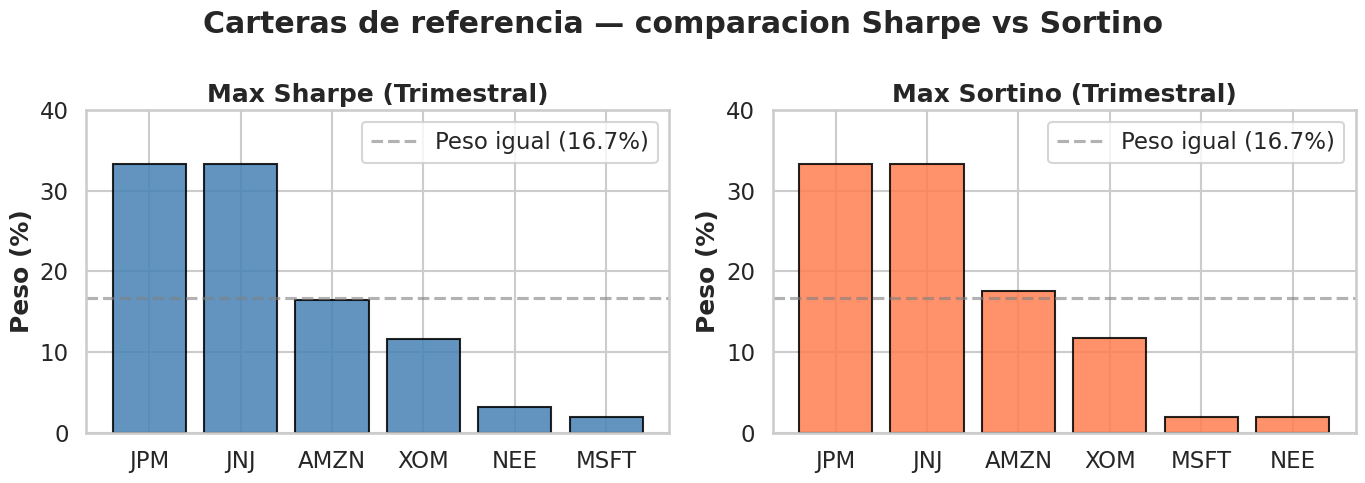

In [15]:
m_sh = full_portf_metrics(w_ref_sharpe,  63)
m_so = full_portf_metrics(w_ref_sortino, 63)

# --- Tabla comparativa de metricas ---
print(f'CARTERAS DE REFERENCIA — Horizonte Trimestral (scipy)\n{"="*60}')
print(f'{"Metrica":28s} {"Max Sharpe":>13s}   {"Max Sortino":>13s}')
print('-' * 60)
for label, key, fmt_str in [
    ('Retorno trimestral',    'mu',      '{:>12.2f}%'),
    ('Volatilidad',           'sig',     '{:>12.2f}%'),
    ('CVaR 95% ↓ (downside)', 'cvar',    '{:>12.2f}%'),
    ('CVaR 95% ↑ (upside)',   'cvar_up', '{:>12.2f}%'),
    ('Sharpe',                'sharpe',  '{:>13.3f}'),
    ('Sortino',               'sortino', '{:>13.3f}'),
]:
    mult = 100 if key in ('mu', 'sig', 'cvar', 'cvar_up') else 1
    v_sh = fmt_str.format(m_sh[key] * mult)
    v_so = fmt_str.format(m_so[key] * mult)
    print(f'{label:28s} {v_sh}   {v_so}')

# --- Tabla de pesos con diferencia ---
print(f'\n{"Ticker":8s} {"Max Sharpe":>12s}   {"Max Sortino":>12s}   {"Diferencia":>12s}')
print('-' * 52)
for t, ws, wso in zip(ticker_list, w_ref_sharpe, w_ref_sortino):
    diff  = (wso - ws) * 100
    arrow = '▲' if diff > 0.5 else ('▼' if diff < -0.5 else ' ')
    print(f'{t:8s} {ws*100:>11.1f}%   {wso*100:>11.1f}%   {arrow}{abs(diff):>10.1f}pp')

# --- Visualizacion lado a lado ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, w_ref, title, color in [
    (axes[0], w_ref_sharpe,  'Max Sharpe (Trimestral)',  'steelblue'),
    (axes[1], w_ref_sortino, 'Max Sortino (Trimestral)', 'coral'),
]:
    sorted_pairs = sorted(zip(ticker_list, w_ref), key=lambda x: -x[1])
    ticks_s, weights_s = zip(*sorted_pairs)
    ax.bar(ticks_s, [wi * 100 for wi in weights_s], color=color, edgecolor='black', alpha=0.85)
    ax.axhline(100 / len(ticker_list), color='gray', linestyle='--', alpha=0.6,
               label=f'Peso igual ({100/len(ticker_list):.1f}%)')
    ax.set_ylabel('Peso (%)', fontweight='bold')
    ax.set_ylim(0, 40)
    ax.set_title(title, fontweight='bold')
    ax.legend()

plt.suptitle('Carteras de referencia — comparacion Sharpe vs Sortino', fontweight='bold')
plt.tight_layout()
plt.show()
